In [578]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sn
 
 

In [507]:
# INPUT FILES
exp_file = "rna_seq.csv"
meta_file = "metadata.csv"

In [579]:
exp_df = pd.read_csv("/Users/Bioinfo_data/miRNA_compartments_analysis/data/processed/miRNA_count_matrix.csv", index_col=0)

In [580]:
meta_df = pd.read_csv("/Users/Bioinfo_data/miRNA_compartments_analysis/data/processed/metadata_mirna.csv", index_col=0)

In [581]:
# Align samples
common = exp_df.columns.intersection(meta_df.index)
#matching reorder
exp_df = exp_df[common]
meta_df = meta_df.loc[common]

In [583]:
print("Aligned:", exp_df.columns.equals(meta_df.index))

Aligned: True


In [511]:
print("exp_df shape:", exp_df.shape)

exp_df shape: (2982, 45)


In [512]:
print("meta_df Shape:", meta_df.shape)

meta_df Shape: (45, 4)


In [513]:
#check the sample for matching order
matches = exp_df.columns == meta_df.index
print(f"Do all samples match in order? {matches.all()}")

Do all samples match in order? True


In [602]:
print("Any NaN?", exp_df.isna().any().any())
#print(exp_df.isna().sum())
print("Duplicate genes:", exp_df.index[exp_df.index.duplicated()].unique().tolist())
print("Duplicate samples:", exp_df.columns[exp_df.columns.duplicated()].unique().tolist())
print("Non-numeric:", exp_df.select_dtypes(exclude=['number']).columns.tolist())


Any NaN? False
Duplicate genes: []
Duplicate samples: []
Non-numeric: []


In [599]:
exp_df = exp_df.fillna(0)

In [517]:
print("--- Expression Head ---")
display(exp_df.iloc[:5, :5])

--- Expression Head ---


,SRR25680444_exo,SRR25680445_exo,SRR25680447_exo,SRR25680448_exo,SRR25680449_exo
miRNA,,,,,
hsa-let-7a-1,2995,3255,8441,5934,707
hsa-let-7a-2,2977,3255,8432,5928,707
hsa-let-7a-3,2986,3256,8477,5945,707
hsa-let-7a-5p,0,0,0,0,0
hsa-let-7b,5088,5197,17534,23638,1247


In [588]:
print("\n--- Metadata Head ---")
display(meta_df.head())


--- Metadata Head ---


,Patient,Compartment,,Unnamed: 4
SRR25680444_exo,P15,exo,NaN,NaN
SRR25680445_exo,P14,exo,NaN,NaN
SRR25680447_exo,P13,exo,NaN,NaN
SRR25680448_exo,P12,exo,NaN,NaN
SRR25680449_exo,P11,exo,NaN,NaN


In [521]:
#if there is duplicated in dataset then we neeed to first gene or sample by the following code.
##exp_df = exp_df[~exp_df.index.duplicated(keep="first")]
#Take average (biologically safer sometimes)
#exp_df = exp_df.groupby(exp_df.index).mean()
#Sum values (for counts data)
#exp_df = exp_df.groupby(exp_df.index).sum()

In [522]:
#Identify Missing Values (NaN)
#Missing data (NaN) must be handled because most machine learning algorithms cannot process them.
# Counts every NaN value in the entire table
total_missing = exp_df.isna().sum()
print(f"Total missing value: {total_missing}")

Total missing value: SRR25680444_exo    0
SRR25680445_exo    0
SRR25680447_exo    0
SRR25680448_exo    0
SRR25680449_exo    0
SRR25680450_exo    0
SRR25680451_exo    0
SRR25680452_exo    0
SRR25680454_exo    0
SRR25680455_exo    0
SRR25680456_exo    0
SRR25680457_exo    0
SRR25680458_exo    0
SRR25680459_exo    0
SRR25680460_exo    0
SRR25680461_cf     0
SRR25680462_cf     0
SRR25680465_cf     0
SRR25680466_cf     0
SRR25680467_cf     0
SRR25680468_cf     0
SRR25680469_cf     0
SRR25680470_cf     0
SRR25680471_cf     0
SRR25680472_cf     0
SRR25680473_cf     0
SRR25680474_cf     0
SRR25680476_cf     0
SRR25680477_cf     0
SRR25680478_cf     0
SRR25680400_ti     0
SRR25680409_ti     0
SRR25680420_ti     0
SRR25680431_ti     0
SRR25680442_ti     0
SRR25680453_ti     0
SRR25680464_ti     0
SRR25680475_ti     0
SRR25680479_ti     0
SRR25680480_ti     0
SRR25680483_ti     0
SRR25680484_ti     0
SRR25680485_ti     0
SRR25680486_ti     0
SRR25680487_ti     0
dtype: int64


In [523]:
#Verify Data Types
#Sometimes numeric data is incorrectly read as "text" (object) if there are hidden characters or symbols.
print(exp_df.dtypes)

SRR25680444_exo      int64
SRR25680445_exo      int64
SRR25680447_exo      int64
SRR25680448_exo      int64
SRR25680449_exo      int64
SRR25680450_exo      int64
SRR25680451_exo      int64
SRR25680452_exo      int64
SRR25680454_exo      int64
SRR25680455_exo    float64
SRR25680456_exo      int64
SRR25680457_exo      int64
SRR25680458_exo      int64
SRR25680459_exo      int64
SRR25680460_exo      int64
SRR25680461_cf       int64
SRR25680462_cf       int64
SRR25680465_cf       int64
SRR25680466_cf       int64
SRR25680467_cf       int64
SRR25680468_cf       int64
SRR25680469_cf       int64
SRR25680470_cf       int64
SRR25680471_cf       int64
SRR25680472_cf       int64
SRR25680473_cf       int64
SRR25680474_cf       int64
SRR25680476_cf       int64
SRR25680477_cf       int64
SRR25680478_cf       int64
SRR25680400_ti       int64
SRR25680409_ti       int64
SRR25680420_ti       int64
SRR25680431_ti       int64
SRR25680442_ti       int64
SRR25680453_ti       int64
SRR25680464_ti       int64
S

In [525]:
#Check Metadata Consistency 
#Ensures you don't have "Control" and "control" as separate groups
print(meta_df['Compartment'].value_counts())

Compartment
exo    15
cf     15
ti     15
Name: count, dtype: int64


In [603]:
#Now we can perform the first major biological cleanup: Cell Filtering (Sample QC).
#Calculate the 'Library Size' (Total counts per sample)
sample_sums = exp_df.sum(axis=0)
print(sample_sums.describe())

count    4.500000e+01
mean     3.734796e+05
std      5.980733e+05
min      1.057800e+04
25%      4.527000e+04
50%      1.121100e+05
75%      3.379730e+05
max      3.003724e+06
dtype: float64


In [604]:
threshold = 10000

In [605]:
keep_samples = sample_sums > threshold

In [609]:
exp_df = exp_df.loc[:, keep_samples]
meta_df = meta_df.loc[keep_samples]
exp_df.loc[:, keep_samples]

,SRR25680444_exo,SRR25680445_exo,SRR25680447_exo,SRR25680448_exo,SRR25680449_exo,SRR25680450_exo,SRR25680451_exo,SRR25680452_exo,SRR25680454_exo,SRR25680455_exo,...,SRR25680453_ti,SRR25680464_ti,SRR25680475_ti,SRR25680479_ti,SRR25680480_ti,SRR25680483_ti,SRR25680484_ti,SRR25680485_ti,SRR25680486_ti,SRR25680487_ti
miRNA,,,,,,,,,,,,,,,,,,,,,
hsa-let-7a-1,2995,3255,8441,5934,707,339,2652,31387,269,348.0,...,0,0,0,0,0,0,0,0,0,0
hsa-let-7a-2,2977,3255,8432,5928,707,339,2642,31322,284,349.0,...,0,0,0,0,0,0,0,0,0,0
hsa-let-7a-3,2986,3256,8477,5945,707,347,2646,31317,269,348.0,...,0,0,0,0,0,0,0,0,0,0
hsa-let-7a-5p,0,0,0,0,0,0,0,0,0,0.0,...,246,100,81,53,479,8667,2950,4861,56,82
hsa-let-7b,5088,5197,17534,23638,1247,294,2110,13514,201,165.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hsa-mir-96,5,0,9,0,2,1,1,49,5,2.0,...,0,0,0,0,0,0,0,0,0,0
hsa-mir-98,13,41,875,43,4,17,17,2117,9,12.0,...,0,0,0,0,0,0,0,0,0,0
hsa-mir-9985,1,1,2,0,0,0,0,6,0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [611]:
#Filter BOTH DataFrames to stay in sync
exp_df = exp_df.loc[:, keep_samples]
meta_df = meta_df.loc[keep_samples]
print(f"Removed {sum(~keep_samples)} failed sample(s).")
print(f"Final clean shap: {exp_df.shape}")

Removed 0 failed sample(s).
Final clean shap: (487, 45)


In [614]:
#Verification
#After running this, check the alignment one last time to be safe:
print("Do expression and metadata match perfectly?", exp_df.columns.equals(meta_df.index))

Do expression and metadata match perfectly? True


In [615]:
#Genes filtering
exp_df = exp_df[(exp_df > 1).sum(axis=1) >= 5]
exp_df.shape

(487, 45)

In [616]:
#Look at the statistics
print("--- Gene detected Stats ---")
print(genes_detected_in_samples.describe())

--- Gene detected Stats ---
count    552.000000
mean      13.820652
std        7.248662
min        5.000000
25%        8.000000
50%       13.000000
75%       15.000000
max       30.000000
dtype: float64


In [533]:
#Verification
#After running this, check the alignment one last time to be safe:
print("Do expression and metadata match perfectly?", exp_df.columns.equals(meta_df.index))

Do expression and metadata match perfectly? True


In [537]:
#Normalization (CPM: Counts Per Million)
## We divide by the sum of the column and multiply by 1 million
#Normalization (CPM) & Log2 Transformation

In [617]:
exp_norm = exp_df.div(exp_df.sum(axis=0), axis=1) * 1e6

In [539]:
#Log2 Transformation
#We add +1 because log(0) is impossible.
#This turns the data into a "Bell Curve" for the ML model

In [618]:
exp_log = np.log2(exp_norm + 1)
print("Normalization and log2 complete!")
display(exp_log.head())

Normalization and log2 complete!


,SRR25680444_exo,SRR25680445_exo,SRR25680447_exo,SRR25680448_exo,SRR25680449_exo,SRR25680450_exo,SRR25680451_exo,SRR25680452_exo,SRR25680454_exo,SRR25680455_exo,...,SRR25680453_ti,SRR25680464_ti,SRR25680475_ti,SRR25680479_ti,SRR25680480_ti,SRR25680483_ti,SRR25680484_ti,SRR25680485_ti,SRR25680486_ti,SRR25680487_ti
miRNA,,,,,,,,,,,,,,,,,,,,,
hsa-let-7a-1,14.977277,15.147101,14.508808,14.547834,14.452716,12.246750,15.693350,14.132612,13.147445,13.096917,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000
hsa-let-7a-2,14.968581,15.147101,14.507269,14.546375,14.452716,12.246750,15.687899,14.129621,13.225722,13.101056,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000
hsa-let-7a-3,14.972935,15.147544,14.514948,14.550506,14.452716,12.280393,15.690082,14.129391,13.147445,13.096917,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000
hsa-let-7a-5p,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,13.977083,13.20748,10.923088,10.200132,13.055644,14.182312,13.197803,14.29662,12.05156,11.613459
hsa-let-7b,15.741801,15.822108,15.563445,16.541820,15.271367,12.041326,15.363519,12.917006,12.727089,12.020478,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000


In [541]:
#High Variance Genes (HVG) optional expolration
#gene_variance = exp_log.var(axis=1)
#gene_variance.sort_values(ascending=False).head()

miRNA
hsa-miR-21-5p    62.381747
hsa-mir-10b      57.918480
hsa-miR-7-5p     56.884369
hsa-let-7i       55.227388
hsa-miR-451a     53.266163
dtype: float64

<Axes: >

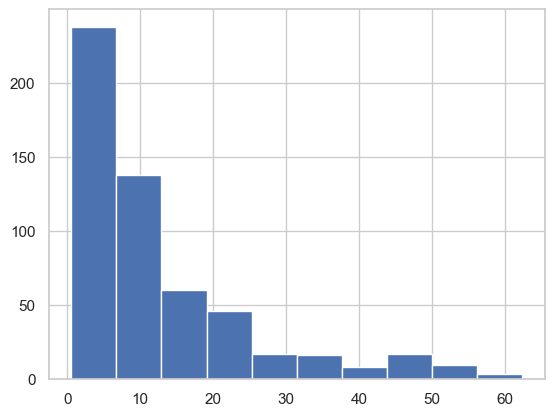

In [542]:
gene_variance.hist()

In [619]:
print(f"Final gene count for ML: {exp_final.shape[0]}")
print(f"Orignal gene count: {exp_log.shape[0]}")
print(f"Selected variance threshold: {top_220_threshold:.4f}")

Final gene count for ML: 221
Orignal gene count: 487
Selected variance threshold: 10.0368


In [544]:
#Machine Learning models (like Random Forest) require the data to have Samples as Rows and Genes as Columns. We need to "flip" the table.

In [620]:
X = exp_log.T

#Prepare the X and y matrices
#Transpose the Expression data (X)
#From (500 genes, 95 samples) to (95 samples, 500 genes)

In [621]:
y = meta_df["Compartment"]
#Extract the Labels (y)
#We take the 'Condition' column from your matched metadata

In [622]:
print("Ready for ML:")

Ready for ML:


In [548]:
#print(X.shape, y.shape)

In [623]:
print(f"Feature (X) shape: {X.shape}")

Feature (X) shape: (45, 487)


In [624]:
print(f"labels (y) shape: {y.shape}")

labels (y) shape: (45,)


In [625]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier


In [626]:
clf_pipeline = Pipeline([
    ('var', VarianceThreshold(threshold=0.1)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [627]:
#cross validation
from sklearn.model_selection import StratifiedKFold, cross_val_score


In [628]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [629]:
scores = cross_val_score(pipeline, X, y, cv=cv)

In [556]:
print("CV Accuracy:", scores)
print("Mean:", scores.mean())
print("Std:", scores.std())

CV Accuracy: [1.         1.         1.         0.88888889 1.        ]
Mean: 0.9777777777777779
Std: 0.04444444444444447


In [630]:
#Permutation test (VALIDATION)
y_shuffled = y.sample(frac=1, random_state=42).values

shuffled_scores = cross_val_score(pipeline, X, y_shuffled, cv=cv)


In [576]:
print("Shuffled Accuracy:", shuffled_scores)
print("Mean:", shuffled_scores.mean())

Shuffled Accuracy: [0.55555556 0.55555556 0.22222222 0.22222222 0.        ]
Mean: 0.31111111111111117


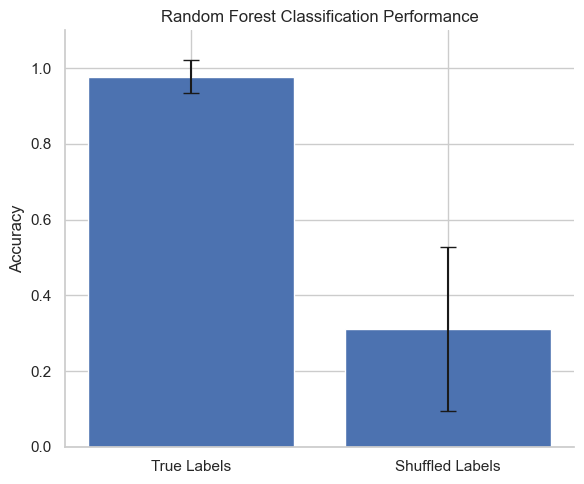

In [676]:
true_scores = np.array([1.0, 1.0, 1.0, 0.88888889, 1.0])
shuffled_scores = np.array([0.55555556, 0.55555556, 0.22222222, 0.22222222, 0.0])

# Calculate mean and std
means = [true_scores.mean(), shuffled_scores.mean()]
stds = [true_scores.std(), shuffled_scores.std()]

labels = ["True Labels", "Shuffled Labels"]

# Create figure
plt.figure(figsize=(6,5))

# Bar plot
plt.bar(labels, means, yerr=stds, capsize=6)

# Labels
plt.ylabel("Accuracy")
plt.title("Random Forest Classification Performance")

# Style tweaks (clean journal look)
plt.ylim(0, 1.1)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Remove top/right borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Save
plt.savefig("ML_accuracy_plot.pdf", dpi=300)

plt.show()

In [631]:
#Train model on full data (for interpretation)
pipeline.fit(X, y)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('var', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",10.0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight w

In [632]:
#Extract top miRNAs (IMPORTANT)

In [633]:
#from sklearn.ensemble import RandomForestClassifier
#raining the Random Forest

In [634]:
#Initialize the mode
#random_state=42 ensures you get the same result every time you run it
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [635]:
# Train the model (The "Learning" phase)
model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [636]:
mask = pipeline.named_steps['var'].get_support()
selected_features = X.columns[mask]

In [637]:
importances = pd.Series(
    pipeline.named_steps['rf'].feature_importances_,
    index=selected_features
)

In [566]:
top_10 = importances.sort_values(ascending=False).head(10)
print(top_10)

miRNA
hsa-miR-451a       0.051332
hsa-miR-7-5p       0.037238
hsa-miR-30d-5p     0.027022
hsa-miR-379-5p     0.021878
hsa-miR-21-5p      0.021831
hsa-miR-106a-5p    0.020951
hsa-miR-20b-5p     0.020288
hsa-miR-378i       0.019540
hsa-let-7c-5p      0.015804
hsa-miR-378c       0.015054
dtype: float64


In [638]:
#Visualization (BIOLOGICAL, NOT ML)
top_names = top_10.index.tolist()

In [639]:
subset = exp_log.loc[top_names]

In [640]:
# Calculate means per compartment
ti_mean = subset.loc[:, meta_df['Compartment'] == 'ti'].mean(axis=1)
exo_mean = subset.loc[:, meta_df['Compartment'] == 'exo'].mean(axis=1)
cf_mean = subset.loc[:, meta_df['Compartment'] == 'cf'].mean(axis=1)


In [641]:
plot_df = pd.DataFrame({
    "Tissue": ti_mean,
    "Exosome": exo_mean,
    "Cell-Free": cf_mean
})

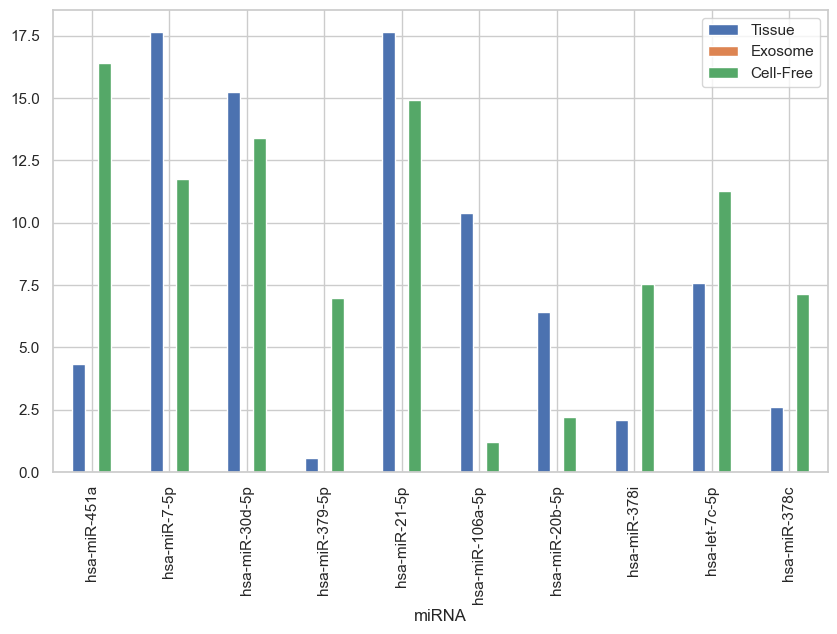

In [642]:
plot_df.plot(kind="bar", figsize=(10,6))
plt.savefig("/Users/jasmu/Desktop/ml_top10.pdf", dpi=300, bbox_inches="tight")

In [653]:
ti_samples = meta_df.index[meta_df['Compartment'] == 'ti']
cf_samples = meta_df.index[meta_df['Compartment'] == 'cf']
exo_samples = meta_df.index[meta_df['Compartment'] == 'exo']

In [662]:
results = []

for common_name, ids in mapping.items():

    mature_gene = ids.get('mature')
    precursor_gene = ids.get('precursor')

    # check existence
    mature_ok = mature_gene in exp_log.index
    precursor_ok = precursor_gene in exp_log.index if precursor_gene else False

    # TI and CF (mature only)
    ti_val = exp_log.loc[mature_gene, ti_samples].mean() if mature_ok else np.nan
    cf_val = exp_log.loc[mature_gene, cf_samples].mean() if mature_ok else np.nan

    # EXO (precursor if exists)
    if precursor_ok:
        exo_val = exp_log.loc[precursor_gene, exo_samples].mean()
    else:
        exo_val = np.nan

    # final append (FIXED)
    results.append({
        'miRNA': common_name,
        'Tissue (Mature)': ti_val,
        'Exo (Precursor)': exo_val,
        'Cell-Free (Mature)': cf_val
    })

In [663]:
hybrid_summary = pd.DataFrame(results).set_index('miRNA')

print(hybrid_summary.round(2))

         Tissue (Mature)  Exo (Precursor)  Cell-Free (Mature)
miRNA                                                        
miR-7              17.65            11.81               11.76
miR-193             3.38             8.07                8.24
miR-106            10.39              NaN                1.20
let-7i             13.56            15.51               15.61
miR-451             4.33            13.60               16.40
miR-99b             9.00            11.77               11.34
miR-21             17.63            14.87               14.91


In [664]:
#Create a small table comparing mir vs miR for your top marker
comparison_table = pd.DataFrame({
    'Exo_Precursor (mir)': [exp_log.loc['hsa-mir-21', exo_ids].mean()],
    'Exo_Mature (miR)': [exp_log.loc['hsa-miR-21-5p', exo_ids].mean()],
    'Tissue_Mature (miR)': [exp_log.loc['hsa-miR-21-5p', meta_df['Compartment']=='ti'].mean()]
}, index=['miR-21/mir-21'])

print("--- The interpretation of Precursor Packaging ---")
print(comparison_table)


--- The interpretation of Precursor Packaging ---
               Exo_Precursor (mir)  Exo_Mature (miR)  Tissue_Mature (miR)
miR-21/mir-21            14.867726               0.0            17.627847


In [665]:
# Calculate means using the correct 'Compartment' column
# We compare 'exo' vs 'ti' (use lowercase or uppercase based on your data)
exo_means = X_pre.loc[meta_df['Compartment'].str.lower() == 'exo'].mean()
ti_means = X_pre.loc[meta_df['Compartment'].str.lower() == 'ti'].mean()

# Calculate Enrichment (The difference in log2 scale)
enrichment = exo_means - ti_means

print("--- Top Novel Exosome-Enriched Precursors ---")
print(enrichment.sort_values(ascending=False).head(10))


--- Top Novel Exosome-Enriched Precursors ---
miRNA
hsa-mir-10b      15.599272
hsa-mir-423      15.183511
hsa-mir-21       14.866938
hsa-mir-26a-2    14.513882
hsa-mir-26a-1    14.513053
hsa-mir-122      14.509404
hsa-mir-10a      14.364239
hsa-mir-100      13.866620
hsa-mir-99a      13.701256
hsa-mir-451a     13.596282
dtype: float64


In [666]:
#Define the pairs for your top precursors
# (Note: We use the mature forms that correspond to your precursor discoveries)
mapping = {
    'hsa-mir-10b': 'hsa-miR-10b-5p',
    'hsa-mir-21': 'hsa-miR-21-5p',
    'hsa-mir-122': 'hsa-miR-122-5p',
    'hsa-mir-100': 'hsa-miR-100-5p',
    'hsa-mir-451a': 'hsa-miR-451a',
    'hsa-mir-423': 'hsa-miR-423-5p',
    'hsa-mir-26a-1': 'hsa-miR-26a-5p',
    'hsa-mir-99a': 'hsa-miR-99a-5p'
}
 

In [667]:
# Calculate means for each stage of the journey
# We use the full exp_log and original meta_df
ti_mat = exp_log.loc[list(mapping.values()), meta_df['Compartment'] == 'ti'].mean(axis=1)
exo_pre = exp_log.loc[list(mapping.keys()), meta_df['Compartment'] == 'exo'].mean(axis=1)
cf_mat = exp_log.loc[list(mapping.values()), meta_df['Compartment'] == 'cf'].mean(axis=1)


In [668]:
#Combine into a comparison dataframe
journey_df = pd.DataFrame({
    'Tissue (Mature)': ti_mat.values,
    'Exo (Precursor)': exo_pre.values,
    'Cell-Free (Mature)': cf_mat.values
}, index=mapping.keys())

print("--- The miRNA Processing Journey ---")
print(journey_df.round(2))


--- The miRNA Processing Journey ---
               Tissue (Mature)  Exo (Precursor)  Cell-Free (Mature)
hsa-mir-10b              14.10            15.60               15.34
hsa-mir-21               17.63            14.87               14.91
hsa-mir-122               9.46            14.51               16.12
hsa-mir-100              13.22            13.87               14.82
hsa-mir-451a              4.33            13.60               16.40
hsa-mir-423              13.40            15.18               15.45
hsa-mir-26a-1            12.09            14.51               13.92
hsa-mir-99a              12.50            13.70               13.59


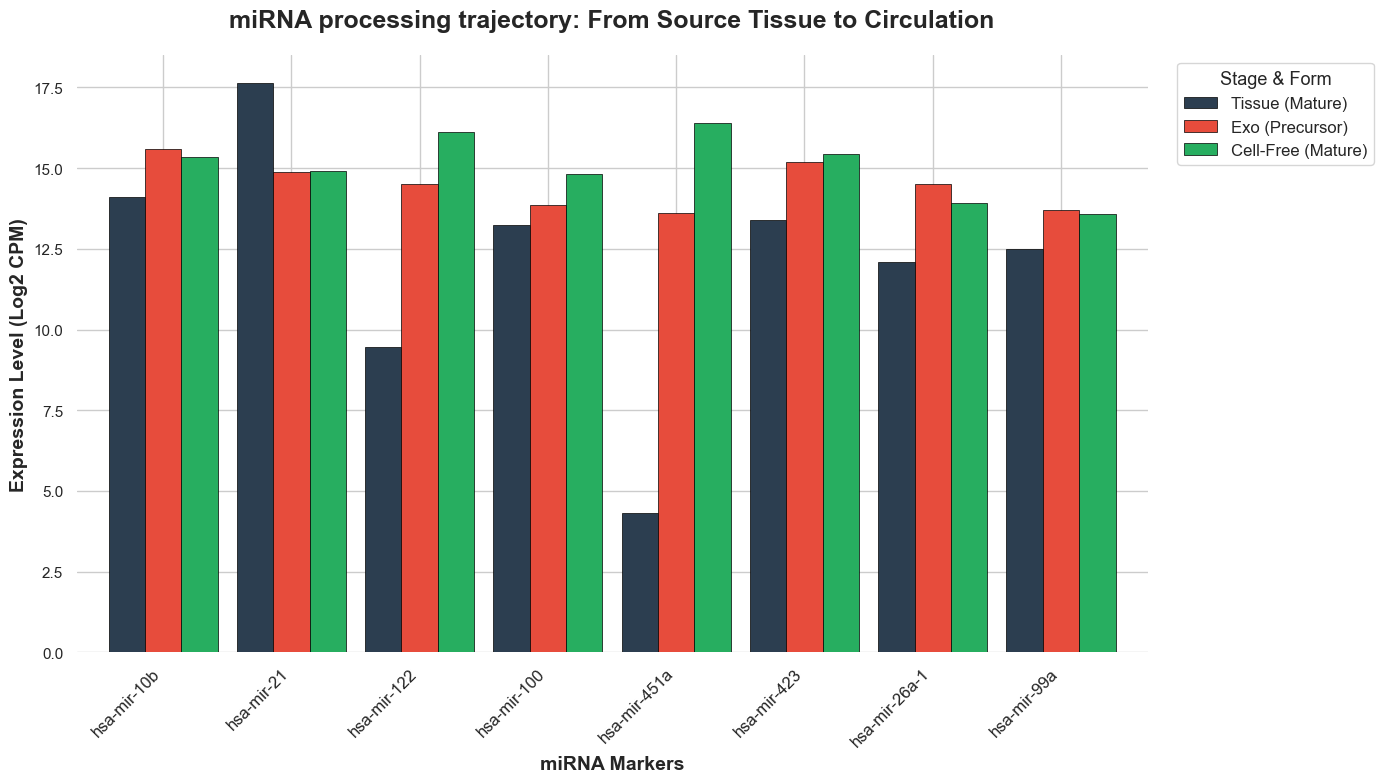

The plot is now ready and saved


In [674]:
# Testataan, että seaborn latautuu oikein
sns.set_theme(style="whitegrid")

# Piirretään aiemmin luomamme "Professional Plot"
colors = ['#2c3e50', '#e74c3c', '#27ae60']
ax = journey_df.plot(kind='bar', figsize=(14, 8), width=0.85, color=colors, edgecolor='black', linewidth=0.5)

plt.title("miRNA processing trajectory: From Source Tissue to Circulation", fontsize=18, fontweight='bold', pad=20)
plt.ylabel("Expression Level (Log2 CPM)", fontsize=14, fontweight='semibold')
plt.xlabel("miRNA Markers", fontsize=14, fontweight='semibold')
plt.xticks(rotation=45, ha='right', fontsize=12)

plt.legend(title="Stage & Form", labels=['Tissue (Mature)', 'Exo (Precursor)', 'Cell-Free (Mature)'], 
           fontsize=12, title_fontsize=13, bbox_to_anchor=(1.02, 1), loc='upper left')

sns.despine(left=True, bottom=True)
plt.tight_layout()

# Tallennus
plt.savefig("miRNA_Processing trajectory_Plot.pdf", dpi=300, bbox_inches='tight')
plt.show()

print("The plot is now ready and saved")


In [670]:
import os
os.getcwd()

'/Users/jasmu'